# Exploratory Data Analysis (EDA)

We need to get to know more about our training dataset. We will only use training dataset (not including val or test set) to prevent data leakage from happening (getting insight from future data while it is prohibited and not possible in real case).

In [5]:
import warnings
warnings.filterwarnings("ignore")

import sys
import os
sys.path.append(os.path.abspath(".."))

In [6]:
from src.utils.utils import ConfigManager
import pandas as pd 
from matplotlib import pyplot as plt
import seaborn as sns

In [7]:
# Usage configuration manager
config_manager = ConfigManager('config/config.yaml')
# Load the config
config = config_manager.load_config()
config

{'features': {'categorical': ['person_home_ownership',
   'loan_intent',
   'loan_grade',
   'cb_person_default_on_file'],
  'numerical': ['person_age',
   'person_income',
   'person_emp_length',
   'loan_amnt',
   'loan_int_rate',
   'loan_percent_income',
   'cb_person_cred_hist_length']},
 'path': {'interim_data': '/Users/apa/Documents/DATAKU/BootCamp/Pacmann/ML_API/mentoring/new_credit_scoring/data/interim',
  'path_config': '/Users/apa/Documents/DATAKU/BootCamp/Pacmann/ML_API/mentoring/new_credit_scoring/config/config.yaml',
  'processed_data': '/Users/apa/Documents/DATAKU/BootCamp/Pacmann/ML_API/mentoring/new_credit_scoring/data/processed',
  'raw_data': '/Users/apa/Documents/DATAKU/BootCamp/Pacmann/ML_API/mentoring/new_credit_scoring/data/raw/credit_risk_dataset.csv',
  'test_data': '/Users/apa/Documents/DATAKU/BootCamp/Pacmann/ML_API/mentoring/new_credit_scoring/data/interim/test.pkl',
  'train_data': '/Users/apa/Documents/DATAKU/BootCamp/Pacmann/ML_API/mentoring/new_credit_sc

In [8]:
# Load Train Data
train_data_path = config['path']['train_data']
# Deserialization
data_train = config_manager.deserialize_data(train_data_path)

In [9]:
X_train = data_train['X_train']
y_train = data_train['y_train']
display(
    X_train.sample(5),
    y_train.sample(5)
)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
17521,24,83100,RENT,5.0,PERSONAL,E,5000,16.35,0.06,Y,3
6650,26,48000,RENT,0.0,PERSONAL,E,6000,16.45,0.13,N,4
1082,22,65500,RENT,4.0,EDUCATION,B,17600,10.74,0.27,N,2
22317,27,27720,RENT,1.0,EDUCATION,B,7000,10.95,0.25,N,6
7408,22,53000,MORTGAGE,6.0,DEBTCONSOLIDATION,C,1000,15.27,0.02,Y,4


22641    0
16595    0
29259    1
11714    0
5402     0
Name: loan_status, dtype: int64

In [10]:
num_cols = ['person_age','person_income','person_emp_length','loan_amnt','loan_int_rate','loan_percent_income','cb_person_cred_hist_length']
cat_cols = ['person_home_ownership','loan_intent','loan_grade','cb_person_default_on_file']

In [11]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19544 entries, 352 to 23660
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  19544 non-null  int64  
 1   person_income               19544 non-null  int64  
 2   person_home_ownership       19544 non-null  object 
 3   person_emp_length           19008 non-null  float64
 4   loan_intent                 19544 non-null  object 
 5   loan_grade                  19544 non-null  object 
 6   loan_amnt                   19544 non-null  int64  
 7   loan_int_rate               17669 non-null  float64
 8   loan_percent_income         19544 non-null  float64
 9   cb_person_default_on_file   19544 non-null  object 
 10  cb_person_cred_hist_length  19544 non-null  int64  
dtypes: float64(3), int64(4), object(4)
memory usage: 1.8+ MB


In [12]:
# Check if the same value of numerical features from the list num_cols
set(X_train.describe().columns.to_list()) == set(num_cols)

True

In [13]:
# For cat cols
set(X_train.describe(include='object').columns.to_list())  == set(cat_cols)

True

# Check duplicate for train data

In [14]:
X_train[X_train.duplicated(keep=False)].sort_values(['person_income'], ascending=False).head(20)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
29160,36,250000,RENT,2.0,DEBTCONSOLIDATION,A,20000,7.88,0.08,N,17
32047,36,250000,RENT,2.0,DEBTCONSOLIDATION,A,20000,7.88,0.08,N,17
16926,22,183000,MORTGAGE,3.0,EDUCATION,A,1000,NaN,0.01,N,2
238,22,183000,MORTGAGE,3.0,EDUCATION,A,1000,NaN,0.01,N,2
28095,35,160000,OWN,10.0,VENTURE,B,24000,11.83,0.15,N,9
27677,35,160000,OWN,10.0,VENTURE,B,24000,11.83,0.15,N,9
4639,23,157500,RENT,1.0,EDUCATION,B,10000,12.69,0.06,N,2
17339,23,157500,RENT,1.0,EDUCATION,B,10000,12.69,0.06,N,2
28207,30,150000,RENT,2.0,VENTURE,B,21000,12.62,0.14,N,9
18314,30,150000,RENT,2.0,VENTURE,B,21000,12.62,0.14,N,9


Data yang duplikat akan dihapus dan dipertahankan 1 row saja.

# Check null value

In [15]:
null_df = X_train.isna().sum().to_frame(name='missing_count')
null_df['percentage'] = round(null_df['missing_count'] / len(X_train) * 100 ,2).astype(str) + '%'
null_df

,missing_count,percentage
person_age,0,0.0%
person_income,0,0.0%
person_home_ownership,0,0.0%
person_emp_length,536,2.74%
loan_intent,0,0.0%
loan_grade,0,0.0%
loan_amnt,0,0.0%
loan_int_rate,1875,9.59%
loan_percent_income,0,0.0%
cb_person_default_on_file,0,0.0%


# Check Distribution of Numerical Features

In [16]:
def visualize_num_attributes(
    data: pd.DataFrame,  
    check_outliers: bool, 
    title: str,
    num_cols: list,
    vline_mean: bool=False,
    hue: str=''
) -> None:
    sns.set_style('whitegrid')
    fig, ax = plt.subplots(4, 2, figsize=(14, 10))

    for subax, col in zip(ax.flatten(), num_cols):

        # Value Range
        data_range = f'{data[col].min()} - {data[col].max()}'

        # Plot
        if hue:
            sns.kdeplot(data=data, x=col, hue=hue, ax=subax, fill=True)
        else:
            sns.kdeplot(data=data, x=col, ax=subax, fill=True)

        # Setting
        if check_outliers:
            # Tambah vline utk bounds jika cek outlier
            Q1 = data[col].quantile(.25)
            Q3 = data[col].quantile(.75)
            IQR = Q3 - Q1
            upper_bound = Q3 + 1.5 * IQR
            lower_bound = max(Q1 - 1.5 * IQR, 0)

            subax.axvline(upper_bound, color='red', linestyle='--')
            subax.axvline(lower_bound, color='red', linestyle='--')

        if vline_mean:
            # Vline untuk mean
            col_mean = data[col].mean()
            subax.axvline(col_mean, color='green', linestyle='--')
            
            subax.text(
                col_mean,
                subax.get_ylim()[1]*0.95,
                f"{col_mean:.2f}",
                color='red',
                ha='center',
                va='top',
                fontsize=9,
                fontweight='bold',
            )
        
        subax.set_title(col)
        subax.set_ylabel('')
        subax.set_xlabel('')
        if not hue:
            subax.legend([data_range], title='ranges')

    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


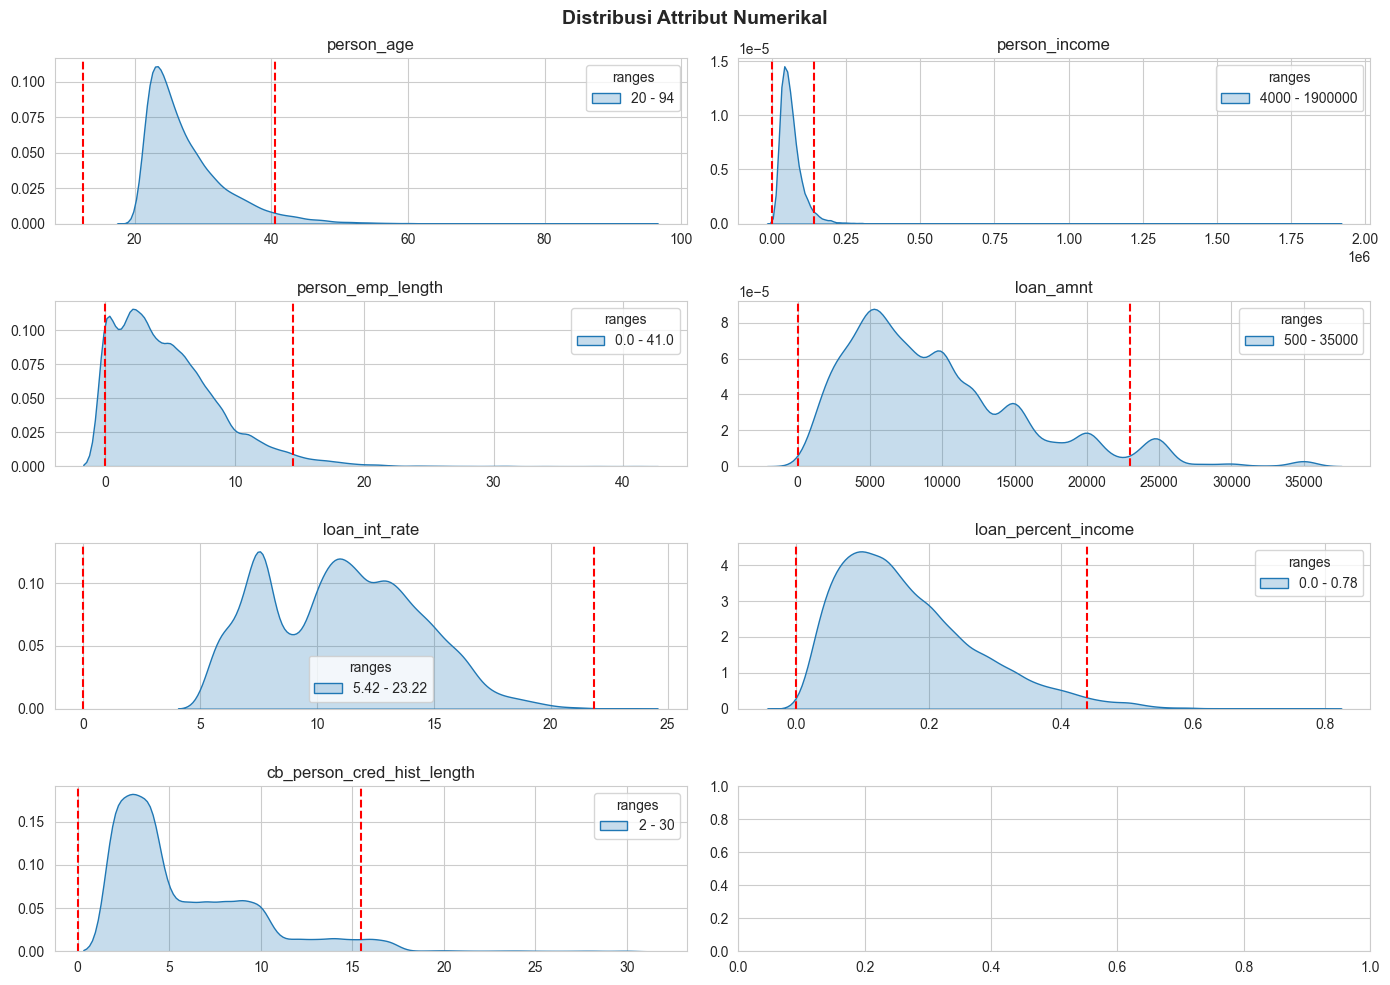

In [17]:
visualize_num_attributes(data=X_train, num_cols=num_cols, check_outliers=True, title="Distribusi Attribut Numerikal")

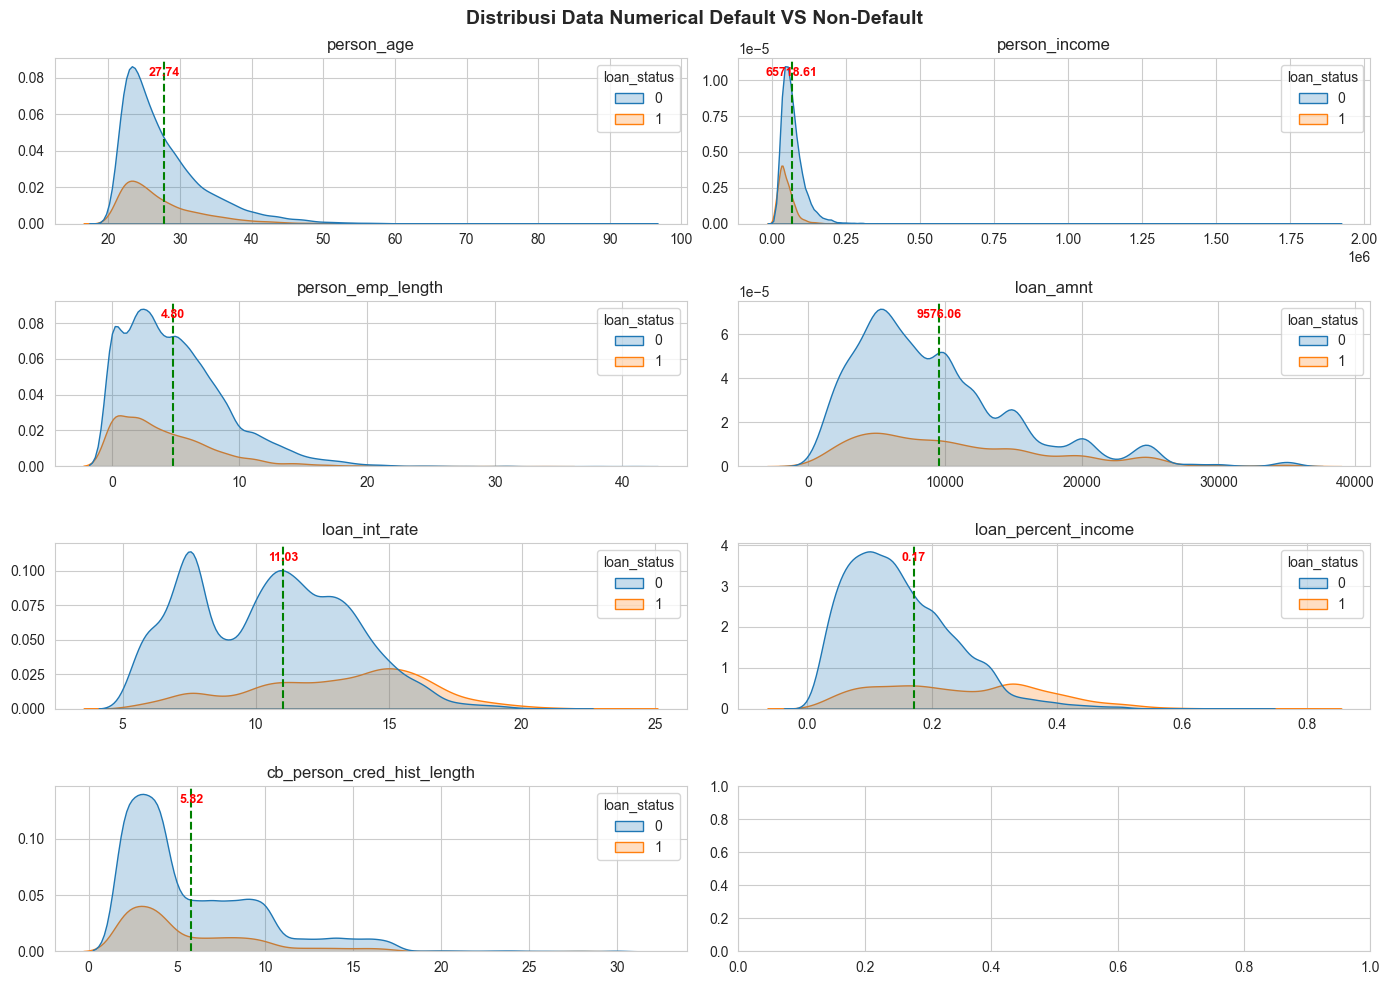

In [18]:
# Cek Distribusi Default dan None Default dengan menampilkan vline
# untuk rata-rata keseluruhan data
visualize_num_attributes(
    data=pd.concat([X_train, y_train], axis=1), 
    check_outliers=False, 
    num_cols=num_cols,
    title="Distribusi Data Numerical Default VS Non-Default", 
    hue='loan_status',
    vline_mean=True
)

# Insight

Data keseluruhan memiliki distribusi right skwed diana menandakan adanya outlier, akan tetapi outliers tetap dipertahankan untuk menjaga informasi data sesungguhnya. Akan tetapi akan digunakan logtransform untuk menekan skewness dari distribusi data, dan penskalaan data menggunakan robust scaler yang cocok untuk data berisi outlier.

# Check Categorical Features

In [19]:
def visualize_cat_attributes(data: pd.DataFrame, title: str, hue: str='') -> None:
    # Distribusi data Categorical
    fig, ax = plt.subplots(2, 2, figsize=(15, 8))
    #
    cat_cols = data.describe(include='object').columns

    for subax, col in zip(ax.flatten(), cat_cols):
        if hue:
            sns.countplot(data=data, y=col, hue=hue, ax=subax, palette='husl')
        else:
            sns.countplot(data=data, y=col, ax=subax)

        subax.set_title(col)
        subax.set_ylabel('')

    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


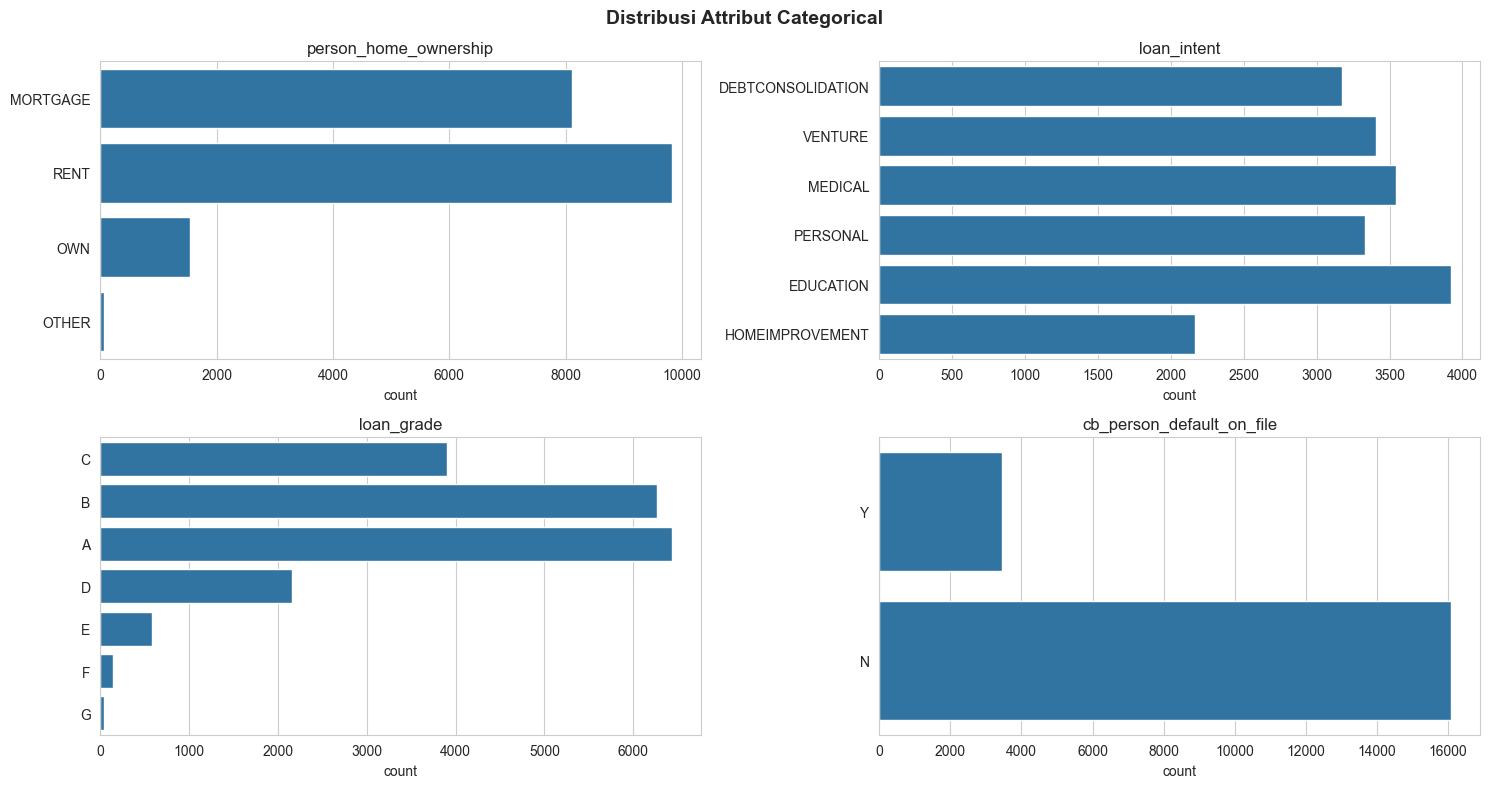

In [20]:
# Cek distribusi data categorical
visualize_cat_attributes(data=X_train, title="Distribusi Attribut Categorical")

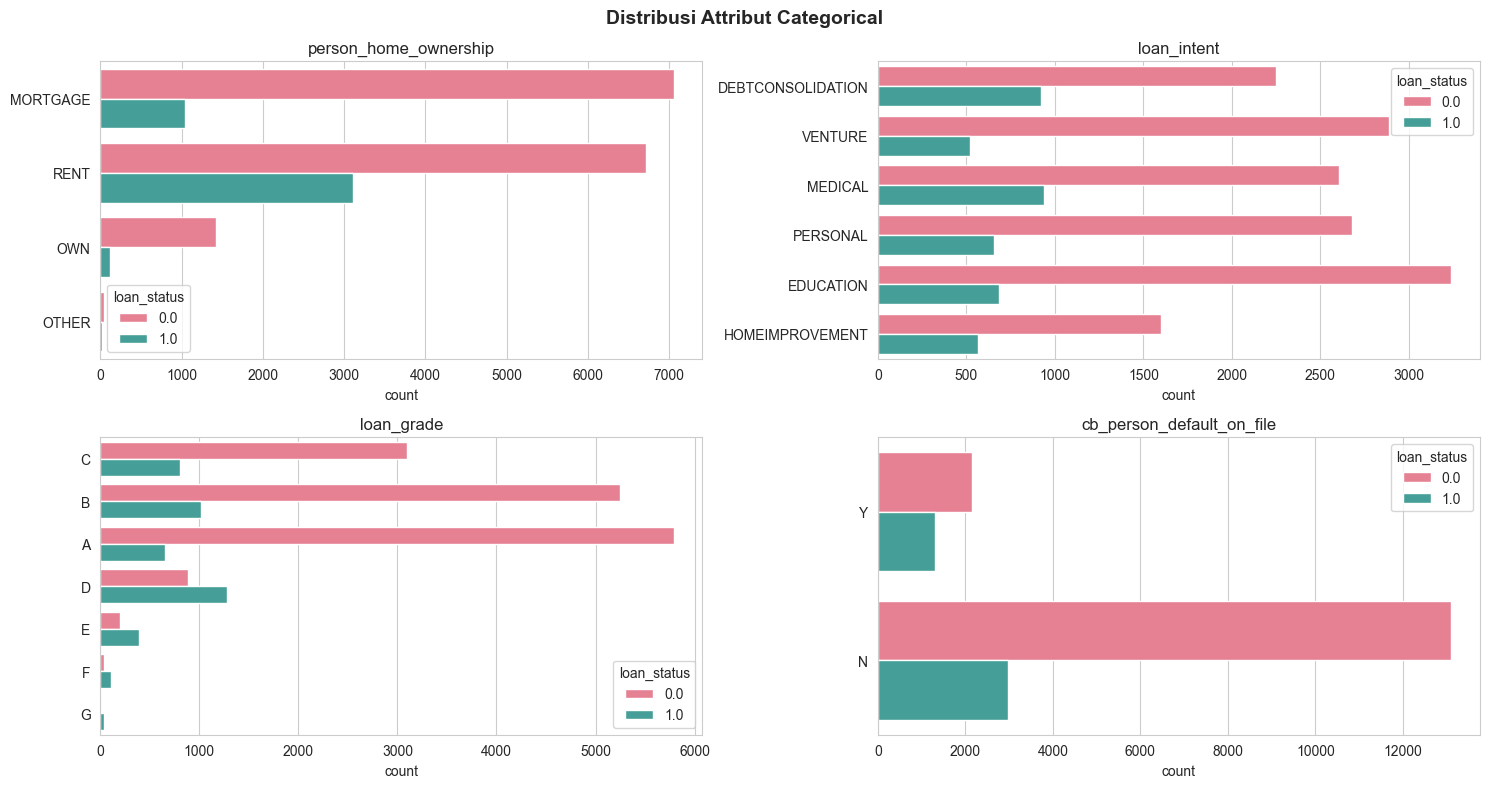

In [21]:
# Cek distribusi data categorical
visualize_cat_attributes(data=pd.concat([X_train, y_train], axis=0), title="Distribusi Attribut Categorical", hue='loan_status')

# Insight

Pada features atau atribut kategorik sepertinya yang akan diterapkan ordinal encoding adalah atribut `loan_grade` dan `cb_person_default_on_file`, untuk `loan_grade` nilai A akan menjadi 1 dan G akan menjadi lebih tinggi, asumsi ini diambil karena dapat dilihat jika `loan_grade` mulai dari D E F dan G banyak mengalami gagal bayar.

# Check Target Distribution

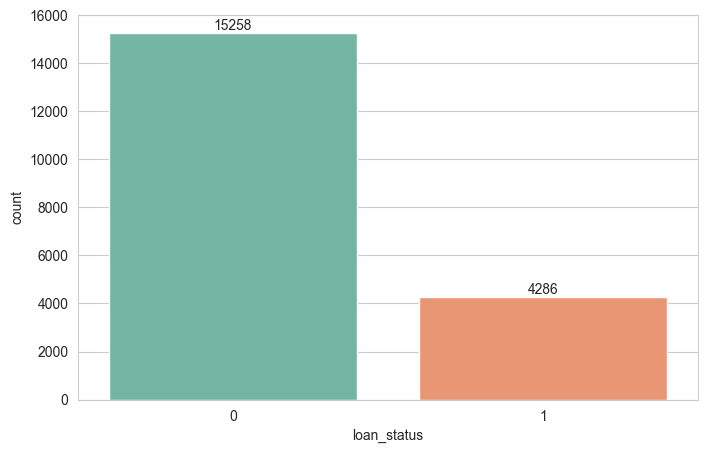

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))

target_plot = sns.countplot(x=y_train, ax=ax, palette='Set2')

for container in target_plot.containers:
    ax.bar_label(container)

plt.show()

# Update config

In [23]:
cat_nominal = ['person_home_ownership','loan_intent']
cat_ordinal = {
    'loan_grade' : {
        'A' : 1,
        'B' : 2,
        'C' : 3,
        'D' : 4,
        'E' : 5,
        'F' : 6,
        'G' : 7
    },
    'cb_person_default_on_file' : {
        'N' : 0,
        'Y' : 1,
    }
}

config_manager.update_config('features.cat_nominal', cat_nominal)
config_manager.update_config('features.cat_ordinal', cat_ordinal)